First we import the library, forcing reload from local version (not pip install). 

In [1]:
import os
import sys
import importlib
import matplotlib.pyplot as plt


# Get the absolute path to the directory containing the local module
stlrom_path = os.path.abspath('../build')
print(stlrom_path)

# Insert the local module path at the beginning of sys.path
sys.path.insert(0, stlrom_path)

import stlrom

# Reload the module to ensure it is loaded from the new path
importlib.reload(stlrom)

import stlrom as sr
import numpy as np

print(sr.Signal.get_interpol())


/home/dayekhh/Documents/git-repos/stlrom2/build
LINEAR


# Signals


## Function


## Test signals

### Basic test signals

### Longer signals

# Testing monitors


In [2]:
stl_parser = stlrom.STLDriver()
stl_parser.parse_string("""signal x, y       # declaring signals named 'x' and 'y'
param p=0.2, tau=5  # declaring parameters named 'p' and 'q'
# Let's add some formulas
mu_x := x[t] > p
mu_x_times := x[t] * tau > p
mu_or := mu_x or mu_x_times
mu_plus_times := x[t] * tau + x[t] > p
phi_x := ev_[0, tau] ( mu_x )
mu_y := y[t] < p 
mu := mu_x and mu_y 
phi_y := y[t]>p => ev_[0, tau] (y[t]<p)
""")


True

In [3]:
# Helper, to add data to a monitor
def add_signals(mon,times, sig_x, sig_y):
    for i in range(0, len(times)):
        mon.add_sample([times[i],sig_x[i],sig_y[i]])
    return mon

# Printing
def print_signal(signal):
    for s in signal.get_samples_list():
        s.print_sample()
    print('begin_time ', signal.begin_time)
    print('end_time    ',signal.end_time)

Monitoring phi_x

## Some plots

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

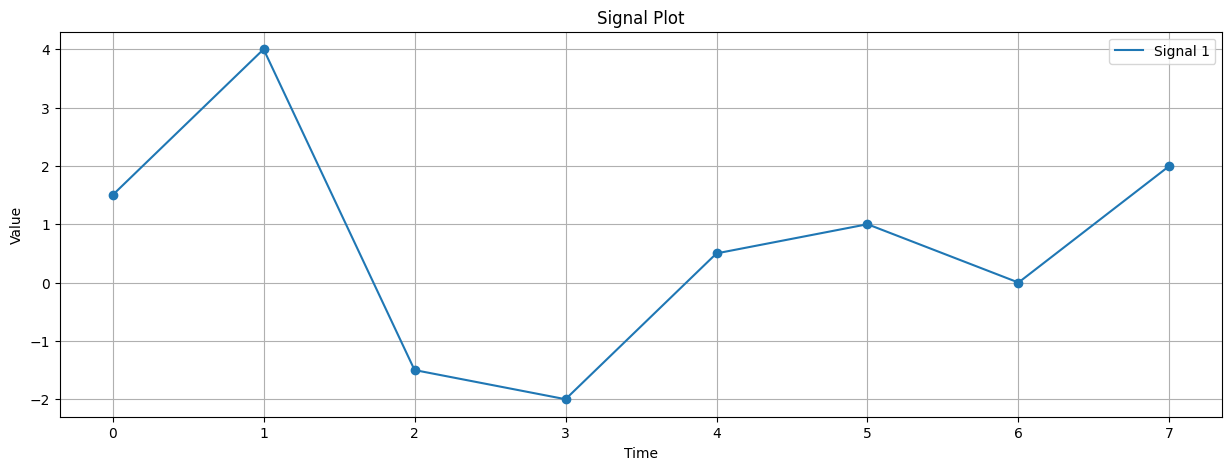

In [4]:

sig_test = sr.Signal()


times = np.array([0, 1, 2, 3, 4, 5, 6, 7])
sig_test_samples = np.array([1.5, 4., -1.5, -2, .5, 1, 0, 2]
)
for t, x in zip(times, sig_test_samples):
    sig_test.append_sample(t, x)

sig_test.plot()


interpol:LINEAR
interpol:LINEAR
interpol:LINEAR
interpol:LINEAR
begin_time  0.0
end_time     7.0
Time 0.00000 Value 1.00000 Derivative 0.00000
Time 1.72727 Value 0.00000 Derivative 0.00000
Time 3.80000 Value 1.00000 Derivative 0.00000
Time 6.00000 Value 0.00000 Derivative 0.00000
Time 6.00000 Value 1.00000 Derivative 0.00000


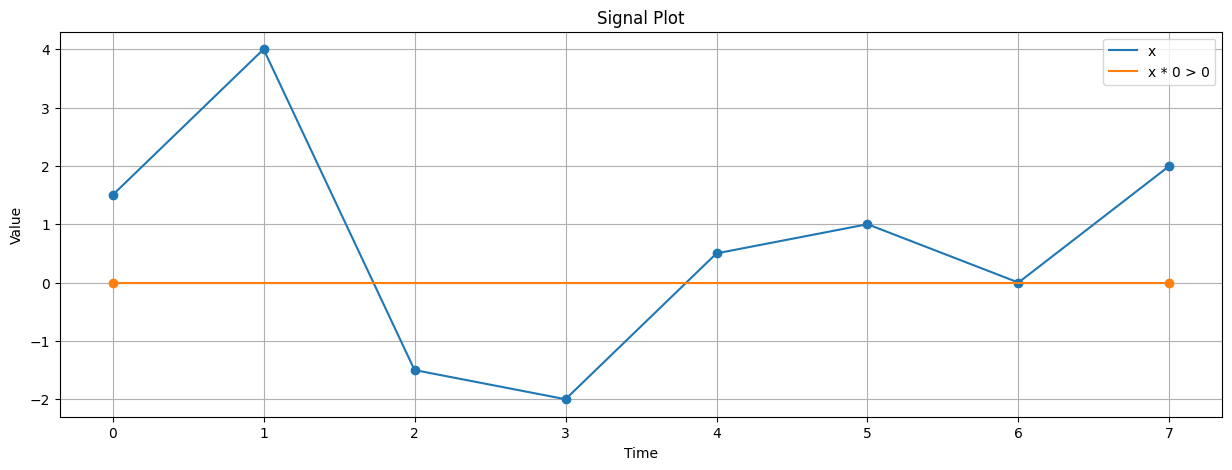

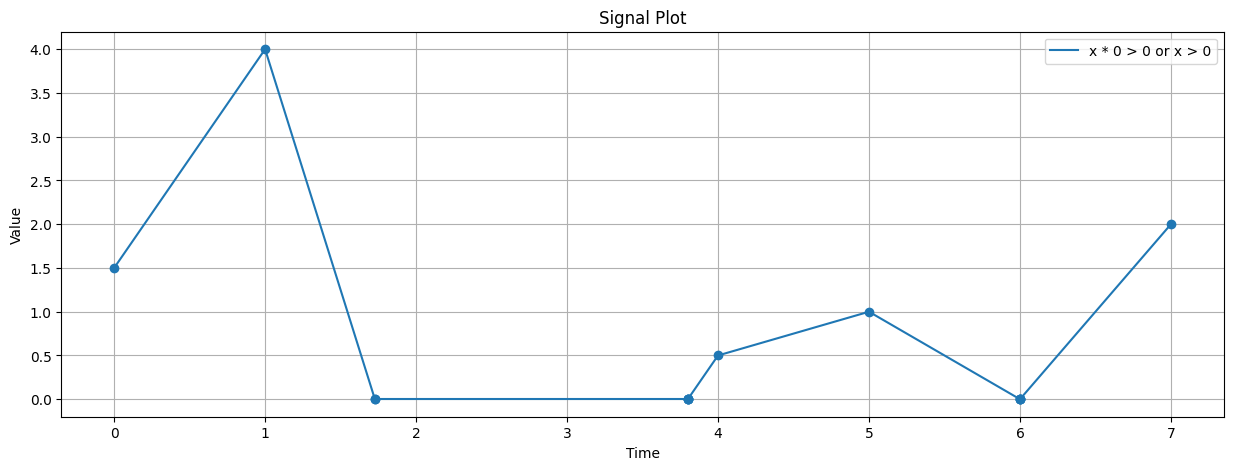

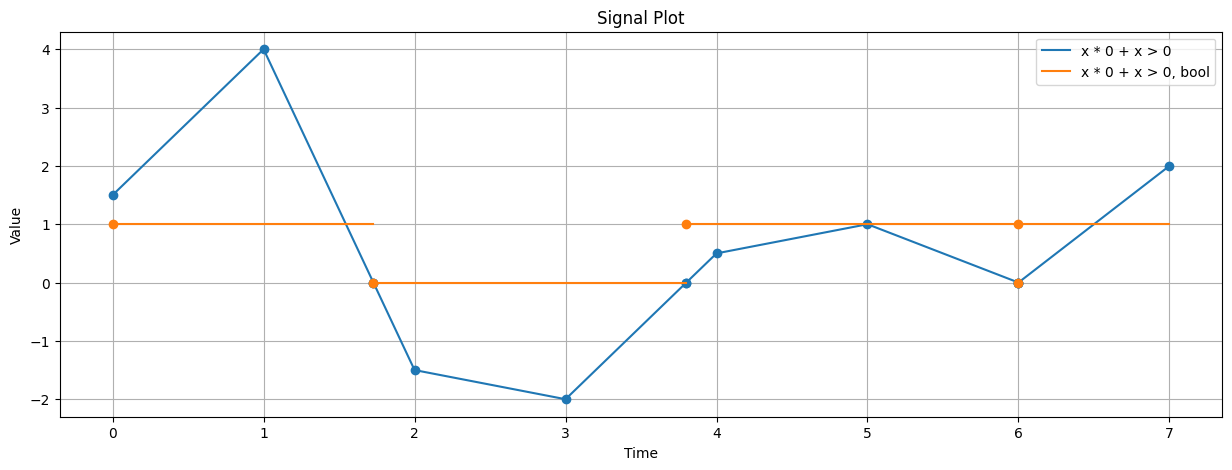

In [5]:
interp = "LINEAR"

sr.Signal.set_Eps(1e-12)
sr.Signal.set_BigM(6)

# mu_x_times is x[t] * tau > p
mu_x_times = stl_parser.get_monitor("mu_x_times")
mu_x_times = add_signals(mu_x_times, times, sig_test_samples, sig_test_samples)
mu_x_times.set_eval_time(times[0], times[-1])
mu_x_times.set_param("p", 0)
mu_x_times.set_param("tau", -0)


# mu_or is x[t] * tau > p
mu_or = stl_parser.get_monitor("mu_or")
mu_or = add_signals(mu_or, times, sig_test_samples, sig_test_samples)
mu_or.set_eval_time(times[0], times[-1])
mu_or.set_param("p", 0)
mu_or.set_param("tau", -0)

# mu_plus_times = (x[t] * tau) + x[t] > p
mu_plus_times = stl_parser.get_monitor("mu_plus_times")
mu_plus_times = add_signals(mu_plus_times, times, sig_test_samples, sig_test_samples)
mu_plus_times.set_eval_time(times[0], times[-1])
mu_plus_times.set_param("p", 0)
mu_plus_times.set_param("tau", -0)


fig = sig_test.plot(label="x")



mu_x_times.set_semantics("SPACE")
mu_x_times.set_interpol(interp)
mu_x_times.eval_rob()
z_times = mu_x_times.formula.z
fig = z_times.plot(label="x * 0 > 0", ax=fig)

mu_or.set_semantics("SPACE")
mu_or.set_interpol(interp)
mu_or.eval_rob()
z_or = mu_or.formula.z
fig = z_or.plot(label = "x * 0 > 0 or x > 0")

mu_plus_times.set_semantics("SPACE")
mu_plus_times.set_interpol(interp)
mu_plus_times.eval_rob()
z_plus_times = mu_plus_times.formula.z
fig = z_plus_times.plot(label = "x * 0 + x > 0")

mu_plus_times.set_semantics("BOOLEAN")
mu_plus_times.set_interpol(interp)
mu_plus_times.eval_rob()
z_plus_times = mu_plus_times.formula.z
fig = z_plus_times.plot(label = "x * 0 + x > 0, bool", ax=fig)
print_signal(z_plus_times)